# Modelo 1 — Forecasting de Precios de Alimentos a 2 Semanas
## Proyecto: food-price-forecasting-peru | UNMSM Big Data Analytics 2025-II

**Contexto del proyecto:**  
Este notebook entrena el Modelo 1 del sistema de alerta temprana de inflación de alimentos básicos en Lima.  
La fuente de datos es una matriz de aprendizaje que integra tres tipos de dato distintos:
- **SISAP-MIDAGRI**: precios mayoristas semanales de alimentos en mercados de Lima
- **SENAMHI**: condiciones climáticas (temperatura, precipitación, heladas) en zonas productoras
- **Twitter/NLP**: sentimiento semanal de tweets sobre precios de alimentos en Lima

El dataset en GCS ya tiene el JOIN entre estas tres fuentes hecho en notebooks anteriores.  
En este notebook se trabaja directamente con pandas (el volumen post-filtro es ~2,800 filas, manejable en memoria).

**Pregunta que responde este modelo:**  
Dado el historial reciente de precios de un alimento, las condiciones climáticas en su zona productora  
y el sentimiento en redes sociales, ¿cuál será su precio mayorista en Lima en 2 semanas?


In [1]:
# Ejecutar solo una vez por sesión de Colab
# !pip install -q mlflow xgboost scikit-learn pandas numpy matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [2]:
# Autenticación y carga desde GCS
from google.colab import auth
from pyspark.sql import SparkSession
import os

# Autenticar con Google
auth.authenticate_user()

# Estos son los paths donde viven los datos procesados en el pipeline anterior
BUCKET_NAME    = "food-price-peru-2025-01"
PATH_MATRIZ    = f"gs://{BUCKET_NAME}/plata/precios_clima_integrado/matriz_aprendizaje_forecasting"
PATH_NLP       = f"gs://{BUCKET_NAME}/plata/tweets_sentimiento_semanal"

# Iniciar Spark con conector GCS
jar_name = "gcs-connector.jar"
if not os.path.exists(jar_name):
    !wget -q https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.14/gcs-connector-hadoop3-2.2.14-shaded.jar -O {jar_name}

os.environ["PYSPARK_SUBMIT_ARGS"] = f"--jars {os.path.abspath(jar_name)} pyspark-shell"

spark = (SparkSession.builder
    .appName("Modelo1_Forecasting")
    .config("spark.hadoop.fs.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem")
    .config("spark.driver.extraClassPath", os.path.abspath(jar_name))
    .config("spark.executor.extraClassPath", os.path.abspath(jar_name))
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate())

# Cargar desde GCS
df_base = spark.read.parquet(PATH_MATRIZ)
df_nlp  = spark.read.parquet(PATH_NLP)

print("Esquema base:")
df_base.printSchema()
print("\nEsquema NLP:")
df_nlp.printSchema()


Esquema base:
root
 |-- producto: string (nullable = true)
 |-- region_clima_origen: string (nullable = true)
 |-- anio: long (nullable = true)
 |-- semana: long (nullable = true)
 |-- precio_promedio: double (nullable = true)
 |-- precio_min: double (nullable = true)
 |-- precio_max: double (nullable = true)
 |-- precio_std: double (nullable = true)
 |-- n_obs: long (nullable = true)
 |-- mercado_sisap: string (nullable = true)
 |-- distrito_lima: string (nullable = true)
 |-- ubigeo_inei: string (nullable = true)
 |-- temp_avg: double (nullable = true)
 |-- temp_max: double (nullable = true)
 |-- temp_min: double (nullable = true)
 |-- precip_total: double (nullable = true)
 |-- humedad_avg: double (nullable = true)
 |-- dias_helada: double (nullable = true)
 |-- dias_lluvia_intensa: double (nullable = true)
 |-- n_obs_clima: double (nullable = true)
 |-- precio_lag_1: double (nullable = true)
 |-- precio_lag_2: double (nullable = true)
 |-- precio_lag_4: double (nullable = true)
 |-

In [3]:
# JOIN con NLP y conversión a Pandas
from pyspark.sql import functions as F

# Alinear fechas en NLP: convertir timestamp a año y semana numéricos
df_nlp_prep = (df_nlp
    .withColumn("anio_nlp",   F.year(F.col("semana")).cast("long"))
    .withColumn("semana_nlp", F.weekofyear(F.col("semana")).cast("long"))
    .dropDuplicates(["anio_nlp", "semana_nlp"])
)

# LEFT JOIN: mantenemos TODAS las filas de precios aunque no haya tweets
df_joined = df_base.join(
    df_nlp_prep,
    (df_base.anio   == df_nlp_prep.anio_nlp) &
    (df_base.semana == df_nlp_prep.semana_nlp),
    how="left"
).select(
    df_base["*"],
    df_nlp_prep["sentiment_promedio"],
    df_nlp_prep["n_tweets"],
    df_nlp_prep["pct_negativo"],
    df_nlp_prep["pct_positivo"]
)

# Convertir a pandas para el resto del pipeline
pdf = df_joined.toPandas()
print(f"Filas tras JOIN: {len(pdf)}")
print(f"Nulos en sentimiento (semanas sin tweets): {pdf['sentiment_promedio'].isnull().sum()}")


Filas tras JOIN: 4697
Nulos en sentimiento (semanas sin tweets): 870


In [4]:
# Filtro agrícola y limpieza de datos

import pandas as pd
import numpy as np

# FILTRO AGRÍCOLA PRIMERO (antes de cualquier imputación)
PRODUCTOS_EXCLUIR = [
    'Pollo Vivo',                                          # pecuario
    'Huevos Rosados',                                      # pecuario
    'Leche Fresca Gloria En Bolsa ( 12 Bolsas De Litro)', # pecuario/procesado
    'Fideos Molitalia Spaghetti / Tallarin'               # industrial procesado
]

pdf = pdf[~pdf['producto'].isin(PRODUCTOS_EXCLUIR)].copy()
print(f"Filas tras filtro agrícola: {len(pdf)}")
print(f"Productos restantes: {sorted(pdf['producto'].unique())}")

# IMPUTACIÓN DE CLIMA con mediana por producto
COLS_CLIMA = ['temp_avg', 'temp_max', 'temp_min', 'precip_total',
              'humedad_avg', 'dias_helada', 'dias_lluvia_intensa', 'n_obs_clima']

for col in COLS_CLIMA:
    # Mediana del propio producto (el más fiel al contexto geográfico)
    pdf[col] = pdf.groupby('producto')[col].transform(lambda x: x.fillna(x.median()))
    # Fallback global por si algún producto no tiene ningún dato de clima
    pdf[col] = pdf[col].fillna(pdf[col].median())

# IMPUTACIÓN DE NLP con 0
COLS_NLP = ['sentiment_promedio', 'n_tweets', 'pct_negativo', 'pct_positivo']
for col in COLS_NLP:
    pdf[col] = pdf[col].fillna(0)

# OTRAS IMPUTACIONES
# precio_std, precio_std_4: variabilidad 0 cuando hay un solo registro
pdf['precio_std']   = pdf['precio_std'].fillna(0)
pdf['precio_std_4'] = pdf['precio_std_4'].fillna(0)
pdf['variacion_1']  = pdf['variacion_1'].fillna(0)

# ELIMINAR SOLO FILAS SIN TARGET
pdf = pdf.dropna(subset=['target_precio_2s'])

print(f"\nFilas finales disponibles: {len(pdf)}")
print(f"Nulos en variables críticas:")
cols_check = ['precio_lag_1', 'precio_lag_2', 'precio_lag_4',
              'temp_avg', 'precip_total', 'dias_helada',
              'sentiment_promedio', 'mes', 'semana', 'target_precio_2s']
print(pdf[cols_check].isnull().sum())


Filas tras filtro agrícola: 2820
Productos restantes: ['Ajo Criollo O Napuri', 'Camote Morado', 'Papa Amarilla', 'Papaya', 'Platano Bellaco', 'Zanahoria']

Filas finales disponibles: 2808
Nulos en variables críticas:
precio_lag_1          0
precio_lag_2          0
precio_lag_4          0
temp_avg              0
precip_total          0
dias_helada           0
sentiment_promedio    0
mes                   0
semana                0
target_precio_2s      0
dtype: int64


In [14]:
# One-Hot Encoding y definición de features optimizada (19 variables finales)
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression

# 1. One-Hot Encoding para los productos agrícolas
pdf_enc = pd.get_dummies(pdf, columns=['producto'], prefix='prod', dtype=int)
prod_cols = [c for c in pdf_enc.columns if c.startswith('prod_')]

# 2. DEFINICIÓN INICIAL COMPLETA (23 variables sugeridas por dominio)
INITIAL_FEATURES = [
    'precio_promedio', 'precio_std', 'precio_lag_1', 'precio_lag_4',
    'precio_std_4', 'variacion_1', 'temp_avg', 'temp_max', 'temp_min',
    'precip_total', 'dias_helada', 'dias_lluvia_intensa', 'humedad_avg',
    'sentiment_promedio', 'pct_negativo', 'pct_positivo', 'n_tweets',
    'mes', 'semana'
] + prod_cols

TARGET = 'target_precio_2s'

# 3. FILTRO ESTADÍSTICO
X_fs = pdf_enc[INITIAL_FEATURES].astype(float).fillna(0)
y_fs = pdf_enc[TARGET]

# ETAPA A: Filtro de Colinealidad (> 0.95)
corr_matrix = X_fs.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
X_filtered = X_fs.drop(columns=to_drop_corr)

# ETAPA B: Filtro de Significancia (p-value < 0.05)
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_filtered, y_fs)
fs_results = pd.DataFrame({'Variable': X_filtered.columns, 'P_Value': selector.pvalues_})

# Quedarse con las significativas
final_features = fs_results[fs_results['P_Value'] < 0.05]['Variable'].tolist()

# 4. AJUSTE DE ESTACIONALIDAD FORZADA (MES + SEMANA)
# Forzamos ambos por ser críticos en agricultura
for forced in ['mes', 'semana']:
    if forced not in final_features:
        final_features.append(forced)

final_features = list(set(final_features))

# 5. CONTROL ESTRICTO DE 19 VARIABLES
# Si hay exceso, removemos variables de NLP de menor impacto para cumplir con la parsimonia de 19
if len(final_features) > 19:
    # Prioridad de descarte: pct_positivo > sentiment_promedio
    for to_remove in ['pct_positivo', 'sentiment_promedio']:
        if to_remove in final_features and len(final_features) > 19:
            final_features.remove(to_remove)

# Ordenar lista final
final_features = sorted(final_features)

print(f"--- FLUJO DE SELECCIÓN FINAL (19 VARIABLES) ---")
print(f"Total final: {len(final_features)} variables")
print(f"\nVariables seleccionadas para el entrenamiento:\n{final_features}")

--- FLUJO DE SELECCIÓN FINAL (19 VARIABLES) ---
Total final: 19 variables

Variables seleccionadas para el entrenamiento:
['dias_lluvia_intensa', 'humedad_avg', 'mes', 'n_tweets', 'pct_negativo', 'precio_lag_4', 'precio_promedio', 'precio_std', 'precio_std_4', 'prod_Ajo Criollo O Napuri', 'prod_Camote Morado', 'prod_Papaya', 'prod_Platano Bellaco', 'prod_Zanahoria', 'semana', 'temp_avg', 'temp_max', 'temp_min', 'variacion_1']


In [15]:
# Split temporal y preparación de matrices
pdf_model = pdf_enc.copy()

# Split temporal estricto: el año es la variable de corte
train = pdf_model[pdf_model['anio'] <= 2022].copy()
test  = pdf_model[pdf_model['anio'] >= 2023].copy()

X_train = train[final_features].astype(float)
y_train = train[TARGET]
X_test  = test[final_features].astype(float)
y_test  = test[TARGET]

print(f"Set de entrenamiento (2017-2022): {len(X_train)} filas")
print(f"Set de evaluación   (2023-2025): {len(X_test)} filas")
print(f"Features: {len(final_features)}")
print(f"\nDistribución del target en test:")
print(y_test.describe())


Set de entrenamiento (2017-2022): 1884 filas
Set de evaluación   (2023-2025): 924 filas
Features: 19

Distribución del target en test:
count    924.000000
mean       2.726045
std        2.710619
min        0.390000
25%        1.396786
50%        1.950000
75%        2.565357
max       33.464286
Name: target_precio_2s, dtype: float64


In [16]:
# Configurar MLflow
import mlflow
import mlflow.sklearn
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# Configurar experimento — el nombre aparece en la UI de MLflow
mlflow.set_tracking_uri("file:///content/mlruns")
mlflow.set_experiment("Forecasting_Precios_Mayoristas_D08")

print(f"MLflow versión: {mlflow.__version__}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print("Experimento configurado: Forecasting_Precios_Mayoristas_D08")

2026/07/09 14:03:58 INFO mlflow.tracking.fluent: Experiment with name 'Forecasting_Precios_Mayoristas_D08' does not exist. Creating a new experiment.


MLflow versión: 3.14.0
Tracking URI: file:///content/mlruns
Experimento configurado: Forecasting_Precios_Mayoristas_D08


In [17]:
# Modelo 1: Regresión Lineal (baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

with mlflow.start_run(run_name="LR_Baseline"):
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)

    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    mae_lr  = mean_absolute_error(y_test, y_pred_lr)
    r2_lr   = r2_score(y_test, y_pred_lr)

    mlflow.log_param("modelo", "LinearRegression")
    mlflow.log_param("n_features", len(final_features))
    mlflow.log_metric("RMSE", rmse_lr)
    mlflow.log_metric("MAE",  mae_lr)
    mlflow.log_metric("R2",   r2_lr)
    mlflow.sklearn.log_model(lr_model, "modelo_lr")

    print(f"Regresión Lineal (Baseline)")
    print(f"  RMSE : {rmse_lr:.4f} soles/kg")
    print(f"  MAE  : {mae_lr:.4f} soles/kg")
    print(f"  R²   : {r2_lr:.4f}")
    print(f"  Interpretación: el modelo se equivoca en promedio {mae_lr:.2f} soles/kg")


2026/07/09 14:04:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Regresión Lineal (Baseline)
  RMSE : 1.0169 soles/kg
  MAE  : 0.3472 soles/kg
  R²   : 0.8591
  Interpretación: el modelo se equivoca en promedio 0.35 soles/kg


In [19]:
# Modelo 2: Random Forest con RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators':    [200, 400, 600, 800],
    'max_depth':       [4, 6, 8, 10, 12],
    'min_samples_leaf':[1, 2, 4, 6],
    'max_features':    [0.3, 0.5, 0.7, 'sqrt'],
}

print(f"Buscando mejores hiperparámetros para Random Forest (n_iter=15)...")

rf_search = RandomizedSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_grid_rf,
    n_iter     = 15,
    cv         = 3,
    scoring    = 'neg_root_mean_squared_error',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)

with mlflow.start_run(run_name="RF_RandomizedSearch"):
    rf_search.fit(X_train, y_train)
    rf_best = rf_search.best_estimator_
    y_pred_rf = rf_best.predict(X_test)

    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    mae_rf  = mean_absolute_error(y_test, y_pred_rf)
    r2_rf   = r2_score(y_test, y_pred_rf)

    mlflow.log_params(rf_search.best_params_)
    mlflow.log_param("modelo", "RandomForest")
    mlflow.log_metric("RMSE", rmse_rf)
    mlflow.log_metric("MAE",  mae_rf)
    mlflow.log_metric("R2",   r2_rf)
    mlflow.sklearn.log_model(rf_best, "modelo_rf")

    print(f"\nRandom Forest — Mejores parámetros: {rf_search.best_params_}")
    print(f"  RMSE : {rmse_rf:.4f} soles/kg")
    print(f"  MAE  : {mae_rf:.4f} soles/kg")
    print(f"  R²   : {r2_rf:.4f}")


Buscando mejores hiperparámetros para Random Forest (n_iter=15)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


2026/07/09 14:09:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Random Forest — Mejores parámetros: {'n_estimators': 200, 'min_samples_leaf': 6, 'max_features': 0.7, 'max_depth': 8}
  RMSE : 1.2471 soles/kg
  MAE  : 0.3982 soles/kg
  R²   : 0.7881


In [20]:
# Modelo 3: XGBoost con RandomizedSearchCV
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

param_grid_xgb = {
    'n_estimators':    [200, 400, 600, 800],
    'learning_rate':   [0.01, 0.05, 0.1],
    'max_depth':       [3, 4, 5, 6],
    'subsample':       [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.7, 0.8, 0.9, 1.0],
    'reg_alpha':       [0, 0.1, 1.0],
    'reg_lambda':      [0.1, 1.0, 5.0],
    'min_child_weight':[1, 3, 5, 7],
}

print(f"Buscando mejores hiperparámetros para XGBoost (n_iter=25)...")

xgb_search = RandomizedSearchCV(
    estimator = xgb.XGBRegressor(
        objective    = 'reg:squarederror',
        random_state = 42,
        n_jobs        = -1,
        verbosity     = 0
    ),
    param_distributions = param_grid_xgb,
    n_iter     = 25,
    cv         = 3,
    scoring    = 'neg_root_mean_squared_error',
    random_state = 42,
    n_jobs      = -1,
    verbose    = 1
)

with mlflow.start_run(run_name="XGB_RandomizedSearch"):
    xgb_search.fit(X_train, y_train)
    xgb_best = xgb_search.best_estimator_
    y_pred_xgb = xgb_best.predict(X_test)

    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
    r2_xgb   = r2_score(y_test, y_pred_xgb)

    mlflow.log_params(xgb_search.best_params_)
    mlflow.log_param("modelo", "XGBoost")
    mlflow.log_metric("RMSE", rmse_xgb)
    mlflow.log_metric("MAE",  mae_xgb)
    mlflow.log_metric("R2",   r2_xgb)
    mlflow.sklearn.log_model(xgb_best, "modelo_xgb", skops_trusted_types=['xgboost.core.Booster', 'xgboost.sklearn.XGBRegressor'])

    print(f"\nXGBoost — Mejores parámetros: {xgb_search.best_params_}")
    print(f"  RMSE : {rmse_xgb:.4f} soles/kg")
    print(f"  MAE  : {mae_xgb:.4f} soles/kg")
    print(f"  R²   : {r2_xgb:.4f}")

Buscando mejores hiperparámetros para XGBoost (n_iter=25)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits


2026/07/09 14:10:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost — Mejores parámetros: {'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  RMSE : 1.2363 soles/kg
  MAE  : 0.3962 soles/kg
  R²   : 0.7918


TABLA COMPARATIVA FINAL — MODELOS DE FORECASTING A 2 SEMANAS
                     Modelo  RMSE (soles/kg)  MAE (soles/kg)       R²
Regresión Lineal (Baseline)         1.016906        0.347180 0.859105
                    XGBoost         1.236296        0.396220 0.791753
              Random Forest         1.247113        0.398168 0.788093

Modelo seleccionado: Regresión Lineal (Baseline)
  RMSE: 1.0169 soles/kg
  R²  : 0.8591


/tmp/ipykernel_1897/1783653124.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature',


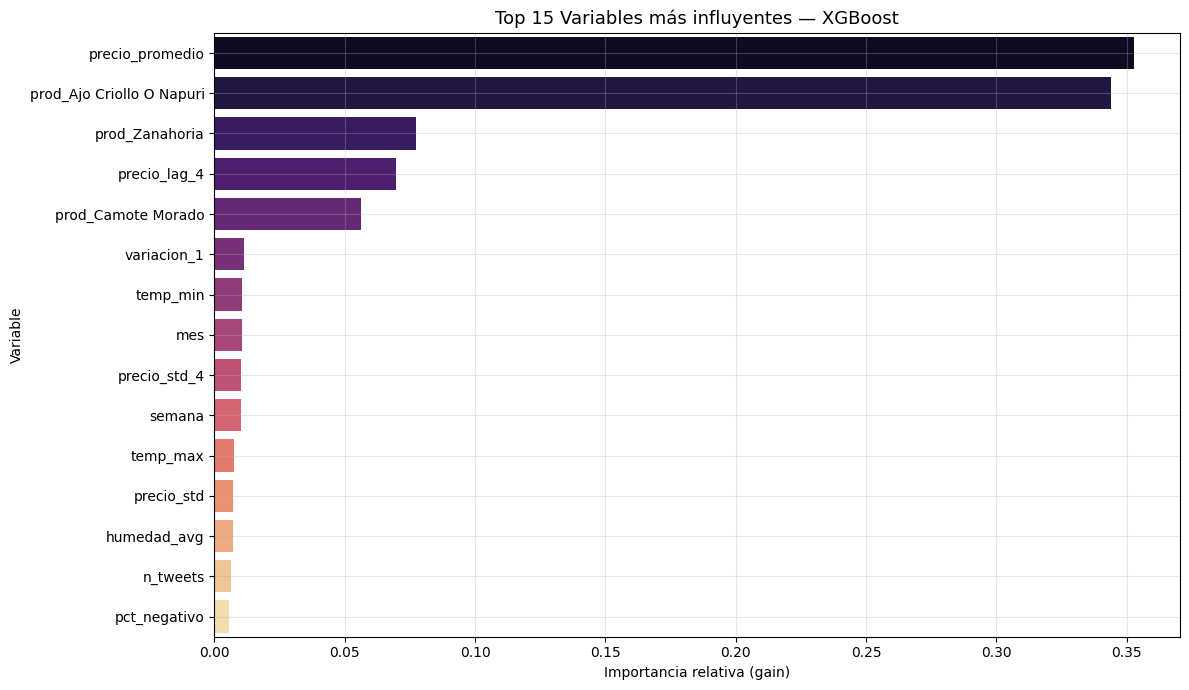

/tmp/ipykernel_1897/1783653124.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature',


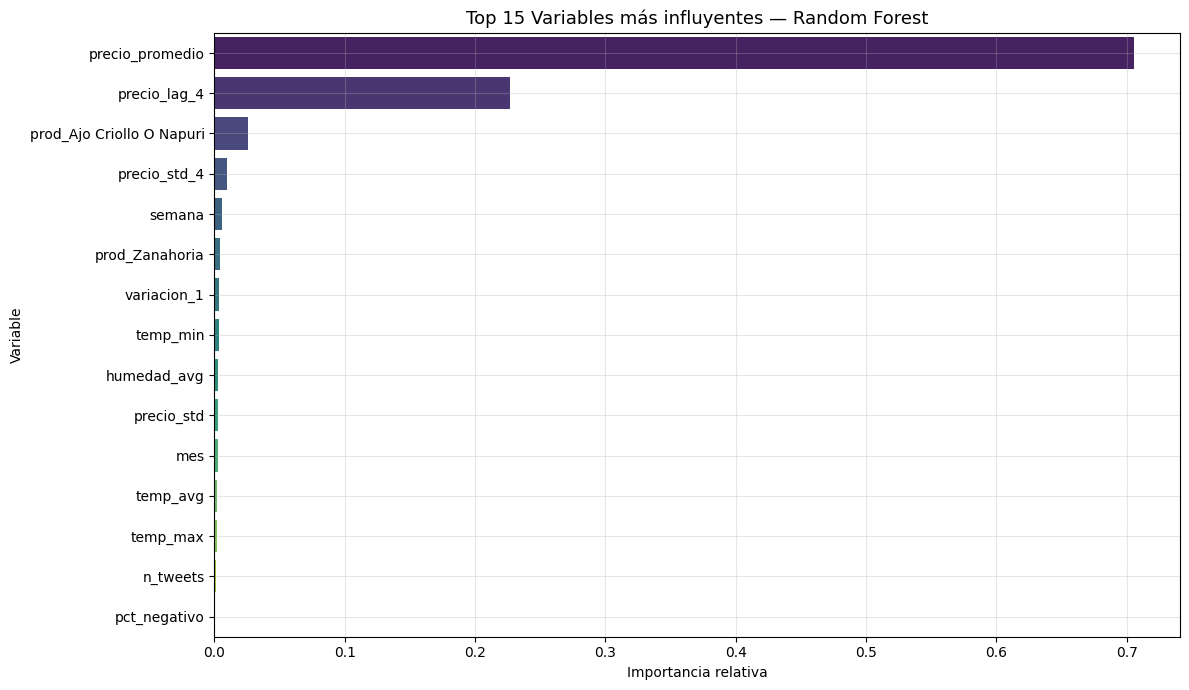

In [21]:
# Tabla comparativa final + Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TABLA COMPARATIVA
comparativa = pd.DataFrame({
    'Modelo':['Regresión Lineal (Baseline)', 'Random Forest', 'XGBoost'],
    'RMSE (soles/kg)': [rmse_lr, rmse_rf, rmse_xgb],
    'MAE (soles/kg)':  [mae_lr,  mae_rf,  mae_xgb],
    'R²':              [r2_lr,   r2_rf,   r2_xgb],
}).sort_values('RMSE (soles/kg)').reset_index(drop=True)

print("=" * 65)
print("TABLA COMPARATIVA FINAL — MODELOS DE FORECASTING A 2 SEMANAS")
print("=" * 65)
print(comparativa.to_string(index=False))
print()

# Identificar ganador
mejor_modelo  = comparativa.iloc[0]['Modelo']
mejor_rmse    = comparativa.iloc[0]['RMSE (soles/kg)']
mejor_r2      = comparativa.iloc[0]['R²']
print(f"Modelo seleccionado: {mejor_modelo}")
print(f"  RMSE: {mejor_rmse:.4f} soles/kg")
print(f"  R²  : {mejor_r2:.4f}")

# FEATURE IMPORTANCE — XGBoost
importancia_xgb = pd.DataFrame({
    'Feature': final_features,
    'Importancia': xgb_best.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importancia', y='Feature',
            data=importancia_xgb.head(15), palette='magma')
plt.title('Top 15 Variables más influyentes — XGBoost', fontsize=13)
plt.xlabel('Importancia relativa (gain)')
plt.ylabel('Variable')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE — Random Forest
importancia_rf = pd.DataFrame({
    'Feature': final_features,
    'Importancia': rf_best.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importancia', y='Feature',
            data=importancia_rf.head(15), palette='viridis')
plt.title('Top 15 Variables más influyentes — Random Forest', fontsize=13)
plt.xlabel('Importancia relativa')
plt.ylabel('Variable')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Guardar modelo ganador en GCS y cerrar MLflow

import pickle
import os

# Guardar el modelo ganador localmente y subirlo a GCS

# Identificar cuál es el mejor
rmse_todos = {'lr': rmse_lr, 'rf': rmse_rf, 'xgb': rmse_xgb}
mejor = min(rmse_todos, key=rmse_todos.get)
modelo_map = {'lr': lr_model, 'rf': rf_best, 'xgb': xgb_best}
modelo_ganador = modelo_map[mejor]

# Guardar localmente
with open(f'modelo_ganador_{mejor}.pkl', 'wb') as f:
    pickle.dump(modelo_ganador, f)
print(f"Modelo ganador guardado: modelo_ganador_{mejor}.pkl")

# Subir a GCS
BUCKET_NAME = "food-price-peru-2025-01"
!gsutil cp modelo_ganador_{mejor}.pkl gs://{BUCKET_NAME}/oro/modelos/modelo1_forecasting.pkl

# Guardar la lista de features para que el dashboard sepa qué columnas esperar
with open('features_modelo1.txt', 'w') as f:
    for feat in final_features:
        f.write(feat + '\n')
!gsutil cp features_modelo1.txt gs://{BUCKET_NAME}/oro/modelos/features_modelo1.txt

print(f"\nModelo y features guardados en GCS.")
print(f"Path: gs://{BUCKET_NAME}/oro/modelos/")

# Descargar mlruns para el repo GitHub
!zip -r mlruns_modelo1.zip /content/mlruns
print("\nDescargar mlruns_modelo1.zip desde el panel de archivos de Colab")
print("y subir al repositorio GitHub en la carpeta /docs/mlruns/")


Modelo ganador guardado: modelo_ganador_lr.pkl
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://modelo_ganador_lr.pkl [Content-Type=application/octet-stream]...

Operation completed over 1 objects/1.1 KiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://features_modelo1.txt [Content-Type=text/plain]...
/ [1 files][  250.0 B/  250.0 B]                                                
Operation completed over 1 objects/250.0 B.                                      

Modelo y features guardados en GCS.
Path: g